# The contribution of FX to portfolio risk
FX and Quantitative Research Issue #2
<br>24 April 2026
<br>*Written by human beings.*

Dominik Mueller, CQF (dominik.mueller@metzler.com)
<br>
<small>
    *Head of Currency Management at Metzler Capital Markets
    <br>https://www.metzler.com/en/metzler/capital-markets/currency-management*
</small>

Maaz Khan (maaz.khan@metzler.com)
<br>
<small>
    *Currency Overlay Manager at Metzler Capital Markets
    <br>https://www.metzler.com/en/metzler/capital-markets/currency-management*
</small>

### Introduction
Foreign exchange rates form a substantial portion of an internationally diversified investment portfolio's risk exposures. How much exactly, and how do exchange rates interact with the underlying investments? Which role do individual currency pairs play? This research brief sets out to answer these questions by way of an empirical analysis of a representative model portfolio from the perspective of an investor based in the euro zone.

We look at volatility and drawdowns as risk measures and intentionally neglect the measurement of return contributions, because we are interested in the implications of our findings for effective risk management strategies. Insofar, our analysis provides a holistic view of the risk contribution of foreign exchange (FX) exposures to the entire portfolio. Some readers will be surprised just how significant the influence of FX on their portfolio returns can be in any given year; others will see the results as a confirmation that FX risk must be taken seriously and might take this as an impetus to reconsider their current risk management process.

In [4]:
# Import all packages required to run the code in this notebook
import pandas as pd  # Data handling, manipulation and I/O
import numpy as np  # Mathematical functions

import plotly.express as px  # Plot charts
import plotly.graph_objects as go  # Plot custom figures
from plotly.subplots import make_subplots  # Create multi-panel subplots

from rich.console import Console  # Formatted console output, i.e. nicer tables
from rich.table import Table

# Load all data required for the analyses set out below
data = pd.read_excel('data.xlsx', sheet_name=None, index_col=0)

### FX losses in 2025
Let us look at past year's spot returns incurred by unhedged European investors with exposures to selected foreign currencies as a motivating example. Figure 1 shows the yearly returns: 2025 was a challenging year in foreign exchange for European asset managers, with most currencies having depreciated significantly versus the euro. The US dollar and Japanese yen, in particular, suffered losses of nearly 12%.

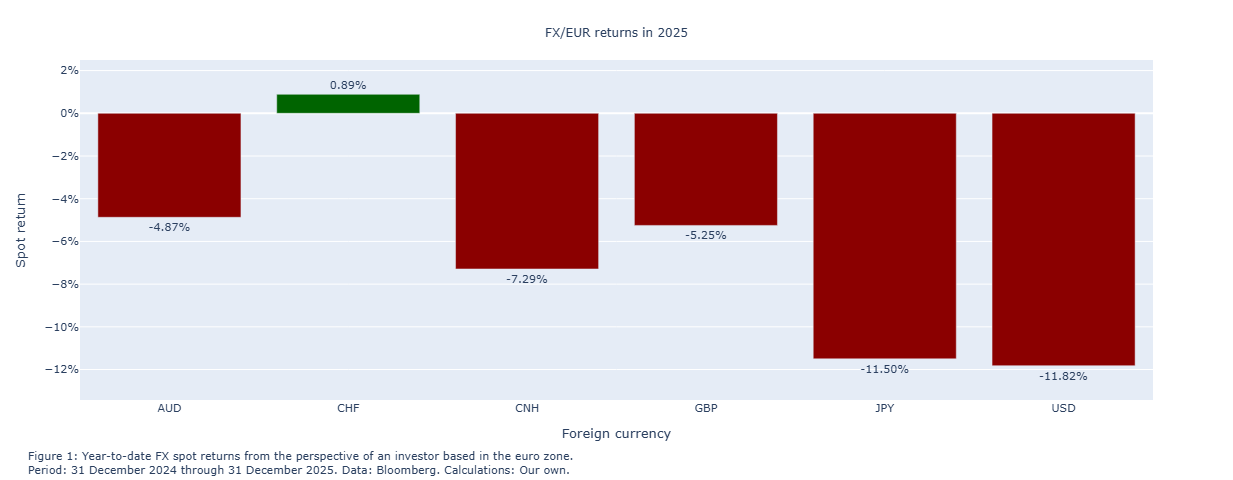

In [5]:
# Load and sort spot returns for 2025
returns = data['fx_returns_2025']
returns = returns[sorted(returns.columns)]

# Plot year-to-date returns
fig = px.bar(
    x=returns.columns,
    y=returns.iloc[0].values,
    labels={'x': 'Foreign currency', 'y': 'Spot return'},
    text_auto=True,
    width=640,
    height=480
)

# Define green/red colors for positive/negative returns
colors = ['darkgreen' if val >= 0 else 'darkred' for val in returns.iloc[0].values]

# Format bar chart
fig.update_traces(
    marker_color=colors,
    textposition='outside',
    texttemplate='%{y:.2%}',
    textfont_size=11
)

# Add title and set y-axis format
title_text = 'FX/EUR returns in 2025'
fig.update_layout(
    title={
        'text': title_text,
        'x': 0.5,
        'y': 0.94,
        'xanchor': 'center',
        'font': dict(size=12)
    },
    yaxis_tickformat=".0%",
    font=dict(size=11)
)

# Add annotation
annotation_text = (
    'Figure 1: Year-to-date FX spot returns from the perspective of an '
    'investor based in the euro zone.<br>Period: 31 December 2024 through '
    '31 December 2025. Data: Bloomberg. Calculations: Our own.'
)

fig.add_annotation(
    text=annotation_text,
    xref="paper",
    yref="paper",
    x=-0.05,
    y=-0.23,
    showarrow=False,
    font=dict(size=11),
    align="left"
)

# Print plot
fig.show()

This is no exception. Although conventional wisdom suggests that exchange rates fluctuate around a long-term equilibrium, history shows numerous periods in which foreign currency exposures have declined in value by 10% or more even within such a relatively short period of time. The point, therefore, is not that foreign exchange is without risk; rather, it is that **FX carries risk for which investors are often not adequately compensated within their portfolios**.

To provide further context to the events of the previous year, reference should be made to the most recent report from the Bank for International Settlements (BIS), published in December 2025. As part of its triennial survey, the BIS traditionally examines foreign exchange market activity during the month of April to ensure enhanced comparability. You will undoubtedly recall that Donald Trump's inconclusiveness regarding tariffs surrounding *Liberation Day* induced heightened volatility. We previously placed the magnitude of the US dollar's movement into a historical context in an earlier article (Mueller, 2025). These events also resulted in daily trading volumes in the global foreign exchange market surging by 27% to an unprecedented USD 9.5 trillion (up from USD 7.5 trillion in 2022) — an increase observed not only in the spot market but also in the demand for currency hedges via forward transactions and options (BIS, 2025).

### Contribution to portfolio risk: Theoretical background
In this paper, as already mentioned, we examine portfolio risk using statistical measures of fluctuation — specifically, the variance and the volatility of the individual investments. Although these measures have certain weaknesses, as we will note in the *aside* section, they have nonetheless established themselves as the standard in risk measurement.

What makes variance particularly interesting is that **it is not a linear measure of fluctuation**. In other words, the portfolio variance is not simply equal to the sum of the variances of the individual assets within the portfolio, because the **covariance** plays a critical role here. If two assets are not perfectly positively correlated, the variance of a combination of these two assets will always be smaller than the simple sum of their individual variances. Put more simply, diversification reduces risk. This is well known, which is why we shall not attempt a mathematical treatment of the concept here.

Our focus lies instead on the precise calculation of the risk contribution of foreign currencies to the portfolio — and the path to this necessarily leads through the portfolio variance. Every introductory textbook on finance (for example, Taylor, 2005) and statistics defines variance as follows:

$$
\sigma^2 = \dfrac{1}{n - 1} \sum_{i=1}^{n} \left( x_i - \bar{x}  \right)^2
$$

and *portfolio variance*, accounting for covariances, as:

$$
\sigma^2_p = \sum_{i=1}^n \sum_{j=1}^n w_i w_j \sigma_{ij}
$$

where $w_i$ and $w_j$ are the weights of assets $i$ and $j$, respectively, and $\sigma_{ij}$ is the covariance between asset returns $i$ and $j$.

This can be written equivalently but more compactly in *matrix form*:

$$
\sigma^2_p = \mathbf{w^T \Sigma w} \tag{1}
$$

where the vector $\mathbf{w}$ holds the weights of all assets in the portfolio, and $\mathbf{\Sigma}$ is the covariance matrix (with the assets' individual variances on the diagonal).

It is more common to express risk as *volatility*, that is, as the standard deviation of value changes. We therefore take the square root and, in order to determine the **marginal risk contribution** of the $i^{th}$ asset to the overall portfolio risk, partially differentiate the portfolio volatility with respect to asset $i$:

$$
\text{MRC}_i = \dfrac{\partial \sigma_p}{\partial w_i} \tag{2}
$$

We say "marginal" risk contribution, because it describes the effect on portfolio volatility by a marginal (i.e. slight) increase in the weight of asset $i$ (Maillard, Roncalli, and Teiletche, 2009). It follows that the asset's (total) **risk contribution** is its marginal risk contribution multiplied by its total weight in the portfolio $w_i$:

$$
\text{RC}_i = w_i \times \dfrac{\partial \sigma_p}{\partial w_i} \tag{3}
$$

It is straightforward to convert this into an expression that we can use more readily in a programmatic setting. Let us start by deriving the marginal risk contribution in matrix form for a simplified portfolio consisting of two assets with weights vector $\mathbf{w} = \begin{pmatrix} w_1 \\ w_2 \end{pmatrix}$ and covariance matrix $\mathbf{\Sigma} = \begin{pmatrix} \sigma_{1} \hspace{0.2cm} \sigma_{12} \\ \sigma_{12} \hspace{0.2cm} \sigma_{2} \end{pmatrix}$:

$$
\begin{align*}
    \dfrac{\partial \sigma_p}{\partial \mathbf{w}} &= \dfrac{\partial \sqrt{\mathbf{w^T \Sigma w}}}{\partial \mathbf{w}} \\[8pt]
    &= \dfrac{\partial}{\partial \mathbf{w}} \sqrt{\begin{pmatrix} w_1 w_2 \end{pmatrix} \begin{pmatrix} \sigma_{1} \hspace{0.2cm} \sigma_{12} \\
            \sigma_{12} \hspace{0.2cm} \sigma_{2} \end{pmatrix} \begin{pmatrix} w_1 \\ w_2 \end{pmatrix}} \\[8pt]
    &= \dfrac{\partial}{\partial \mathbf{w}} \sqrt{w_1^2 \sigma_1 + 2 w_1 w_2 \sigma_{12} + w_2^2 \sigma_2} \\[8pt]
    &= \begin{pmatrix}
            \frac{\partial}{w_1} \sqrt{w_1^2 \sigma_1 + 2 w_1 w_2 \sigma_{12} + w_2^2 \sigma_2} \\
            \frac{\partial}{w_2} \sqrt{w_1^2 \sigma_1 + 2 w_1 w_2 \sigma_{12} + w_2^2 \sigma_2}
        \end{pmatrix} \\[8pt]
    &= \begin{pmatrix}
            \frac{1}{2} \left( w_1^2 \sigma_1 + 2 w_1 w_2 \sigma_{12} + w_2^2 \sigma_2 \right)^{-\tfrac{1}{2}} \left( 2 w_1 \sigma_1 + 2 w_2 \sigma_{12} \right) \\
            \frac{1}{2} \left( w_1^2 \sigma_1 + 2 w_1 w_2 \sigma_{12} + w_2^2 \sigma_2 \right)^{-\tfrac{1}{2}} \left( 2 w_1 \sigma_{12} + 2 w_2 \sigma_2 \right)
        \end{pmatrix} \\[8pt]
    &= \left( w_1^2 \sigma_1 + 2 w_1 w_2 \sigma_{12} + w_2^2 \sigma_2 \right)^{-\tfrac{1}{2}}
        \begin{pmatrix}
            w_1 \sigma_1 + w_2 \sigma_{12} \\
            w_1 \sigma_{12} + w_2 \sigma_2
        \end{pmatrix} \\[8pt]
    &= \dfrac{\mathbf{\Sigma w}}{\sigma_p}
\end{align*}
$$

Hence, the total risk contribution of asset $i$ is given explicitly by

$$
\boxed{\text{RC}_i = w_i \times \dfrac{\left( \mathbf{\Sigma w} \right)_i}{\sigma_p}} \tag{4}
$$

This is a general result. We will use it in our numerical analysis below to compute the impact of foreign exchange exposures on portfolio volatility.

### Aside: Is volatility a measure of risk?
Volatility - measured statistically by the standard deviation of the returns of an asset - is the key measure of "risk" in finance today. It is a key indicator in the determination of optimal portfolios in the mean-variance approach, or modern portfolio theory (MPT), according to Markowitz (1952), as well as in the related calculation of the Sharpe ratio and in the valuation of financial derivatives.

The widespread use of volatility in investment management is due to several factors:
<ul>
    <li>It is easy to understand,</li>
    <li>serves as a standardised measure of price fluctuations,</li>
    <li>and is now standard practice, making it easy to communicate.</li>
</ul>

However, standard volatility measures and their application in practice have drawbacks stemming from simplifying assumptions about return distributions:
<ul>
    <li>They often assume a normal (Gaussian) distribution of price changes, which does not reflect reality.</li>
    <li>Volatility is a backward-looking risk indicator, so its insights may not hold in the future.</li>
    <li>Moreover, volatility in financial markets is not constant but changes over time, especially during crises.</li>
    <li>As a symmetrical measure, volatility does not distinguish between positive and negative price changes.</li>
    <li>Volatility cannot capture risks not evident in price history, such as fundamental developments that have not yet resulted in a risk event.</li>
</ul>

Despite these shortcomings, historical volatility (standard deviation) remains the market standard in practical risk management and portfolio optimisation.

From a risk management perspective, it is important to assess the characteristics of volatility and explore alternative calculation and modelling methods, such as generalised autoregressive conditional heteroscedasticity (GARCH), exponentially weighted moving average (EWMA), local, stochastic, or quantum volatility models. These alternatives can be tailored to different situations, depending on whether historical or expected forward-looking price fluctuations are most relevant, and whether the focus is on strategic or tactical risk allocation decisions - but they require a deep understanding of time-series analysis and stochastics.

Strictly speaking, however, **volatility does not actually tell us anything about risk**. (You may have noticed that we placed "risk" in quotation marks earlier.) We argue that true risk, in the sense of the possibility of loss, is not quantifiable. The reality is that we do not know the true probabilities of future events. In fact, we go so far as to suggest that we cannot even ascertain the probability of risk events *after* they have occurred. Consequently, we cannot determine the likelihood of specific loss scenarios materialising.

Perhaps, then, it is more appropriate to regard volatility as a **measure of uncertainty** or randomness: it quantifies the expected range of outcomes, given certain assumptions about the distribution of returns. However, it is important to remember that actual losses can be significantly greater when genuine risk materialises than what traditional volatility estimates would suggest.

For that reason, this study incorporates an additional section on **historical drawdowns**.

### Data, methodology, and portfolio construction
To quantify the contribution of FX movements to overall portfolio volatility, we construct a globally diversified multi-asset portfolio representative of the holdings of a typical European institutional investor. Our analysis utilises monthly total return data spanning the period from January 2004 to December 2025.

#### Portfolio composition
First, we define a representative portfolio consisting of six asset classes that capture the core components of an institutional strategic asset allocation (SAA), assigning a global index to each:

* 40% Equities: MSCI World (ticker: `MXWO`)
* 30% Bonds: iShares Core Global Aggregate Bond Index (ticker: `LEGATRUU`)
* 15% Real estate: Custom index (see below)
* 5% Private credit: Custom index (see below)
* 5% Private equity: Custom index (see below)
* 5% Gold: Gold spot (ticker: `XAU`)

#### Asset-specific considerations
The illiquid asset classes require a specific treatment and assumptions because of limited data availability:

* Real estate: The INREV European Real Estate Index, published quarterly as a single EUR‑denominated blended series, is converted to monthly frequency using a Brownian bridge, which models a stochastic process between fixed endpoints. Although widely applied in pricing path‑dependent derivatives, this approach also serves for interpolation by populating missing data points while preserving the volatility implied by lower‑frequency observations. As the INREV index cannot be decomposed into regional local‑currency returns directly, we approximate its FX exposure with static country weights, construct a synthetic FX component, and deduct it from the gross EUR series to derive distinct proxy local real estate returns. This method isolates FX risk and prevents double‑counting.

* Private credit: We construct a custom index based on a 20% allocation to the BofA Private Credit Proxy Index (ticker: `MLPRCRED`), which represents the total return of listed business development companies (BDCs) with an emphasis on private credit, and blend it with 30% of the Bloomberg US Corporate Bond Index (ticker: `LUACTRUU`) and 50% of the Bloomberg US Corporate High Yield Bond Index (ticker: `LF98TRUU`), respectively. The resulting index is markedly more risky than a pure bond index, but more bond-like than common proxies based purely on listed BDCs. We assume a 100% exposure to the US dollar.

* Private equity: We create an equally-weighted total return index of 49 listed private equity companies based in the US as a liquid proxy for private equity exposure. This index, too, has a 100% allocation in USD-denominated assets.

#### Return decomposition
The analysis decomposes the total return of each asset class into two distinct components:

* The local return: The underlying return generated by the asset itself in its domestic market.
* The FX return: The return attributable to fluctuations in the currencies in which the assets are denominated.

We use the country weights of each of the indices to derive the FX allocation of each asset class. We then define representative local-currency regional indices and subsequently map the country weights to these regional indices. Holding the weights constant over time, we finally construct stable asset-class return series as the weighted sum of their respective regional components.

By holding the portfolio and regional weights constant, we bypass the issue of portfolio rebalancing and limited availability of historical weights for some indices. This practical approach has the added benefit of enabling us to more accurately measure the risk contribution of FX to the portfolio *ceteris paribus as it is today* based on the most recent data, as opposed to diluting that analysis in the face of historical portfolio changes, which are likely not representative of today's portfolio.

Table 1 presents summary statistics for the monthly total return series by asset class in local currency terms, and for the FX return series.

In [6]:
# Load monthly returns by asset class
asset_returns = data['asset_returns']

# Prepare table
desc = asset_returns.describe()
desc.loc['skew'] = asset_returns.skew()  # Add skewness
desc.loc['kurt'] = asset_returns.kurtosis()  # Add kurtosis

table = Table(
    title="Explorative data analysis",
    caption=("Table 1: Summary statistics for monthly returns across "
             "portfolio asset classes. Period: 2 January 2004 through "
             "31 December 2025. Data: Bloomberg. Calculations: Our own."
    )
)
table.add_column("Statistic", style="bold cyan", no_wrap=True)

for col in desc.columns:
    table.add_column(col, justify="right", style="magenta")

for stat in desc.index:
    if (stat == 'count'):
        row_values = [f"{desc.loc[stat, col]:.0f}" for col in desc.columns]
    else:
        row_values = [f"{desc.loc[stat, col]:.3f}" for col in desc.columns]
    table.add_row(stat, *row_values)

# Print table
console = Console()
console.print(table)

                         Explorative data analysis                          
┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Statistic ┃   Bond ┃ Equity ┃   Gold ┃     PC ┃     PE ┃     RE ┃     FX ┃
┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ count     │    263 │    263 │    263 │    263 │    263 │    263 │    263 │
│ mean      │  0.002 │  0.005 │  0.009 │  0.004 │  0.008 │  0.004 │  0.000 │
│ std       │  0.010 │  0.041 │  0.048 │  0.027 │  0.065 │  0.013 │  0.015 │
│ min       │ -0.034 │ -0.180 │ -0.185 │ -0.184 │ -0.409 │ -0.040 │ -0.054 │
│ 25%       │ -0.003 │ -0.015 │ -0.021 │ -0.005 │ -0.012 │ -0.005 │ -0.009 │
│ 50%       │  0.003 │  0.011 │  0.005 │  0.007 │  0.014 │  0.004 │ -0.000 │
│ 75%       │  0.008 │  0.030 │  0.042 │  0.015 │  0.035 │  0.012 │  0.008 │
│ max       │  0.031 │  0.124 │  0.122 │  0.097 │  0.218 │  0.042 │  0.067 │
│ skew      │ -0.281 │ -0.860 │ -0.178 │ -1.915 │ -1.596 │  0.121 │  0.548 │
│ kurt      │  1.253 │  2.136 │  0.612 │ 13.174 │ 10.012 │  0.245 │  2.705 │
└───────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┘
   Table 1: Summary statistics for monthly returns across portfolio asset   
 classes. Period: 2 January 2004 through 31 December 2025. Data: Bloomberg. 
                           Calculations: Our own.                           

The return series comprise 263 monthly observations each. Whilst FX exhibits a small negative median return, it remains the sole portfolio component displaying meaningful positive skewness—that is, monthly returns clustered below the mean yet featuring a pronounced right tail. This configuration implies upside potential from FX returns, whereas the negative skewness across remaining asset classes signals elevated tail risks. Such portfolio characteristics afford opportunities for FX-centric diversification, albeit necessitating judicious partial hedging to attenuate downside vulnerabilities.

#### Aggregate FX exposure
The portfolio-level FX return series reported in Table 1 reflects the aggregate currency exposure across all asset classes. Individual currency weights are derived by multiplying top-level portfolio weights by the fixed regional weights within each asset class; these are then mapped to their corresponding currency return series and combined into a single portfolio-level FX return series.

The resulting currency basket comprises approximately 36% euro and 64% foreign currencies. Whilst this represents a substantial currency risk from the perspective of an investor from the euro area, it remains consistent with our experience after many years of increasing globalisation and the corresponding portfolio allocations of professional investors. We would contend that a euro weighting of roughly one-third still constitutes a certain *home bias*, given that the eurozone accounts for less than 20% of global equity market capitalisation and only slightly more than 20% of outstanding international debt securities (European Central Bank, 2025).

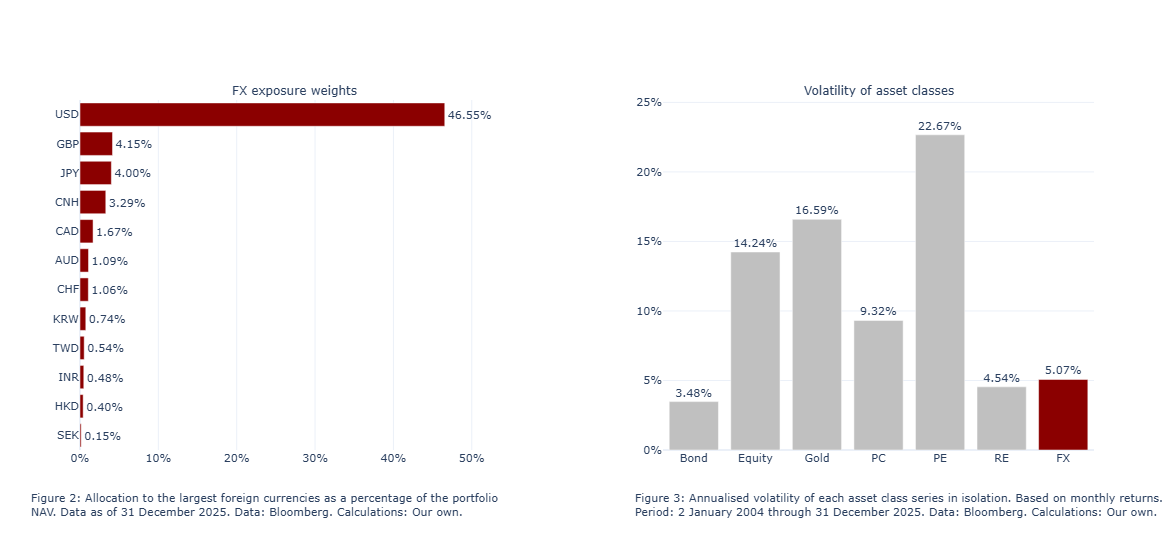

In [7]:
# Load Data
fx_w = data['FX_Allocation'].squeeze("columns")
volatility = data['volatility'].squeeze("columns")

# Set colours
fx_colors = 'darkred'
vola_colors = [
    'darkred' if idx == 'FX' else 'silver'
    for idx in volatility.index
]

# Subplots setup
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("FX exposure weights", "Volatility of asset classes"),
    horizontal_spacing=0.15
)
fig.update_annotations(font_size=12)

# Figure 2: FX weights
fig.add_trace(
    go.Bar(
        y=fx_w.index,
        x=fx_w.values,
        orientation='h',
        marker_color=fx_colors,
        text=fx_w.values,
        texttemplate='%{x:.2%}',
        textposition='outside',
        name="Weights"
    ),
    row=1, col=1
)

# Figure 3: Asset class volatilities
fig.add_trace(
    go.Bar(
        x=volatility.index,
        y=volatility.values,
        marker_color=vola_colors,
        text=volatility.values,
        texttemplate='%{y:.2%}',
        textposition='outside',
        name="Volatility"
    ),
    row=1, col=2
)

# Further formatting
fig.update_layout(
    width=1100,
    height=550,
    font=dict(size=11),
    showlegend=False,
    template="plotly_white",
    margin=dict(b=100)
)

fig.update_xaxes(range=[0, 0.55], tickformat=".0%", row=1, col=1)
fig.update_yaxes(tickformat=".0%", row=1, col=2)

# Add annotation for figure 2
fig2_annotation_text = (
    'Figure 2: Allocation to the largest foreign currencies as a '
    'percentage of the portfolio<br>NAV. Data as of 31 December '
    '2025. Data: Bloomberg. Calculations: Our own.'
)

fig.add_annotation(
    text=fig2_annotation_text,
    xref="paper",
    yref="paper",
    x=-0.05,
    y=-0.2,
    showarrow=False,
    font=dict(size=11),
    align="left"
)

# Add annotation for figure 3
fig2_annotation_text = (
    'Figure 3: Annualised volatility of each asset class series in '
    'isolation. Based on monthly returns.<br>Period: 2 January 2004 '
    'through 31 December 2025. Data: Bloomberg. Calculations: Our own.'
)

fig.add_annotation(
    text=fig2_annotation_text,
    xref="paper",
    yref="paper",
    x=1.07,
    y=-0.2,
    showarrow=False,
    font=dict(size=11),
    align="left"
)

# Show figures
fig.show()

### The results
Our model portfolio exhibits a total volatility of 7.34% per annum. This figure is plausible and remains consistent with various balanced portfolios encountered in our daily professional practice. The risk profile appears deliberately moderate. The inclusion of gold tends to have a variance-reducing effect. However, it should be assumed that the volatility may be somewhat underestimated from a purely mathematical standpoint in the real estate segment of the portfolio, and overestimated for the private market exposures, in particular private credit, where we utilised a listed private credit company index as a proxy. This implies that the private market investments, overall, display a slightly more equity-like risk profile. In practice, they would be valued less frequently and may therefore exhibit smoothed valuation trends.

The findings from our volatility measurement and the subsequent calculation of volatility contributions from the individual asset classes are unequivocal. Although the currency basket, when viewed in isolation, exhibits an annualised volatility of 5.07% (Figure 3), **the risk contribution of foreign currencies within the portfolio ranks second** — surpassed only by equities (Figure 4). Exchange rate fluctuations have contributed nearly 1.6 percentage points to the total portfolio volatility or, to put it another way, *close to one-fifth of the total risk*.

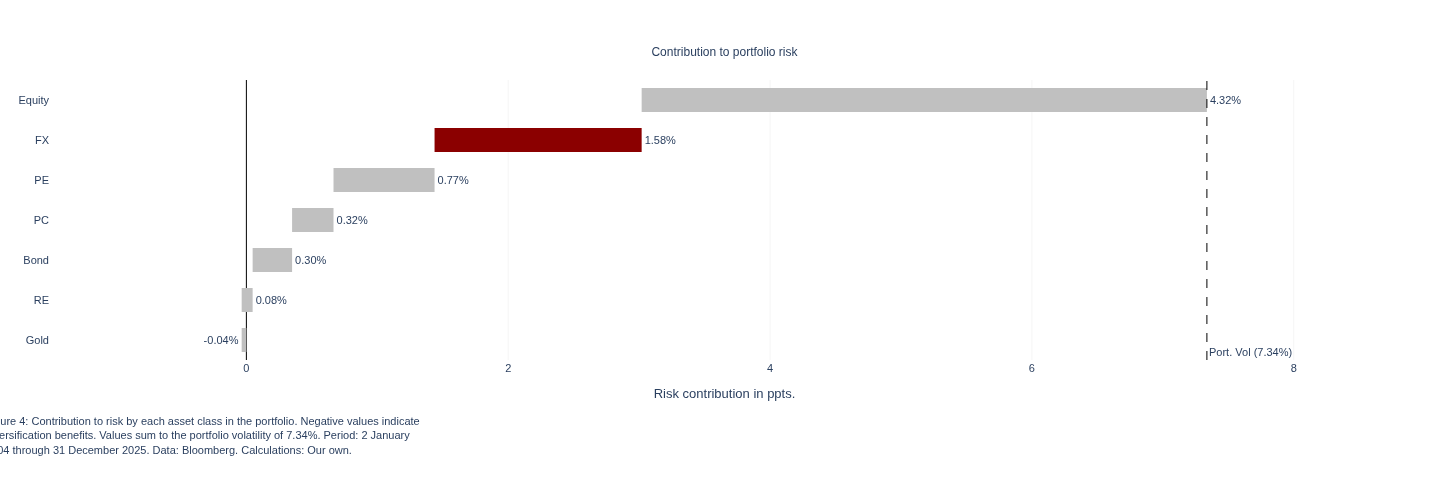

In [8]:
# Load portfolio weights by asset class
w_port = data["portfolio_weights"].squeeze()

# Covariance matrix 
cov = asset_returns.cov() * 12

# Portfolio returns
portfolio_returns = asset_returns.dot(w_port)

# Portfolio volatility
port_vol = np.sqrt(float(w_port.T @ cov @ w_port))  # Equation (1)

# Calculate risk contribution; derived in Eqs. (1)-(4)
mrc = cov @ w_port / port_vol  # Marginal risk contribution: Eq. (2)
rc = w_port * mrc  # Risk contribution: Eq. (4)
rc_pct = rc / port_vol  # Risk contribution relative to total volatility

df = pd.DataFrame({
    "Weight": w_port,
    "MRC": mrc,
    "RC": rc,
    "RC_pct": rc_pct
}).sort_values("RC", ascending=True)

df["start"] = 100 * (df["RC"].cumsum() - df["RC"])

colors = ['darkred' if idx == 'FX' else 'silver' for idx in df.index]

# Create the plot
fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=df.index,
        x=100*df["RC"],
        base=df["start"],
        orientation='h',
        marker=dict(
            color=colors,
            line=dict(color='black', width=0)
        ),
        text=100*df["RC"],
        texttemplate='%{x:.2f}%',
        textposition='outside',
        textfont_size=11,
        width=0.6
    )
)

port_vol_ppt = port_vol * 100
fig.add_vline(
    x=port_vol_ppt,
    line_dash="dash",
    line_color="black",
    line_width=1.0,
    annotation_text=f"Port. Vol ({port_vol:.2%})",
    annotation_position="bottom right"
)

fig.update_layout(
    title={
        'text': "Contribution to portfolio risk",
        'x': 0.5,
        'y': 0.9,
        'xanchor': 'center',
        'font': dict(size=12)
    },
    xaxis_title='Risk contribution in ppts.',
    xaxis=dict(
        range=[-1.5, (df["RC"].sum()) * 120],
        zeroline=True,
        zerolinecolor='black',
        zerolinewidth=1,
        gridcolor='whitesmoke'
    ),
    template="plotly_white",
    width=640,
    height=480,
    font=dict(size=11),
    margin=dict(l=50, r=50, t=80, b=120)
)

# Add annotation note
annotation_text = (
    'Figure 4: Contribution to risk by each asset class in the portfolio. '
    'Negative values indicate<br>diversification benefits. Values sum to '
    'the portfolio volatility of 7.34%. Period: 2 January<br>2004 through '
    '31 December 2025. Data: Bloomberg. Calculations: Our own.'
)

fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=-0.05,
    y=-0.35,
    showarrow=False,
    align="left",
    font=dict(size=11)
)

fig.show()

While this result may appear surprising at first glance, it is naturally a consequence of the high proportion of foreign currencies held within the portfolios of most institutional investors. However, there is also positive news: the inclusion of foreign currencies provides simultaneous diversification benefits, due specifically to the significant weight of the US dollar within the FX basket.

Statistical evidence from recent years supports the **Dollar Smile** theory — the notion that the US dollar tends to perform strongly both during periods of US economic outperformance and during episodes of global market stress. (The term was coined originally by Stephen Li Jen and Fatih Yilmaz, 2001, when they worked at Morgan Stanley.) In this capacity, the US dollar has served as a *safe haven*, at least in recent history, and has exhibited a low or, in some instances, negative correlation with risk assets. Nevertheless, current developments in the relations between the United States and the rest of the world suggest that this risk-mitigating property of the US dollar could diminish, at least in the short term, and cause the smile to morph into a smirk as capital flows may increasingly favour other regions during crises.

This substantial contribution to total portfolio risk is also the reason why most investors opt to hedge a portion of this currency exposure through appropriate hedging instruments. Determining which currencies are best suited for hedging, the criteria upon which such decisions are based, and the extent to which an FX hedge is advisable, falls outside the scope of this article; however, these topics will be addressed in a subsequent publication regarding strategic considerations for foreign currencies.

### The effect of FX on drawdowns
To conclude this article and to build on our analysis of the contribution of foreign currencies to portfolio volatility, we examine their total *actual* ex post risk contribution, as measured by the 12-month rolling **maximum drawdown** — the peak-to-trough decline experienced by the portfolio over a one-year horizon.

As previously noted, while volatility is a widely accepted bilateral measure of dispersion for statistical risk analysis, it does not necessarily reflect realised loss scenarios. Furthermore, as an aggregate metric, it fails to capture the dynamic relationship between currency contributions and the underlying portfolio over time. This latter point is particularly evident in Figure 5, which illustrates the maximum drawdown across the entire observation period for both the unhedged portfolio (indicated in red) and the portfolio with foreign currency exposures fully hedged into EUR (indicated in grey).

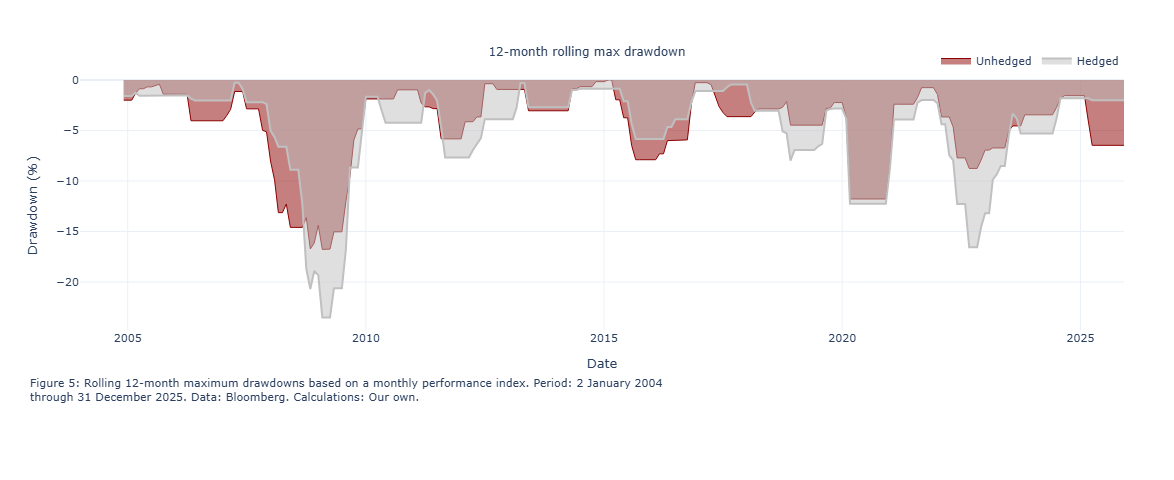

In [20]:
# ---------------------------------------------------------
# Helper functions for index and drawdown calculations
# ---------------------------------------------------------

# Function to compute FX-hedged performance index
def compute_fx_hedge_index(df: pd.DataFrame) -> pd.Series:
    # Copy DataFrame and sort chronologically
    sorted_df = df.copy().sort_values('TIMESTAMP').reset_index(drop=True)

    # Group by FX pair and lag forward prices for calculation
    forward_lag = sorted_df.groupby('SPOT_NAME')['FORWARD'].shift(1)

    # Calculate FX hedge returns
    sorted_df['FWD_RETURN'] = np.where(
        sorted_df['FLAG_ROLL'] == 1, 
        np.log(sorted_df['SPOT_PX']) - np.log(forward_lag), 
        np.log(sorted_df['FORWARD']) - np.log(forward_lag)
    )
    sorted_df['FWD_RETURN'] = sorted_df['FWD_RETURN'].fillna(0)
    sorted_df['FX_HEDGE_INDEX'] = 100 * np.exp(sorted_df['FWD_RETURN'].cumsum())

    return pd.Series(sorted_df['FX_HEDGE_INDEX'].values, index=sorted_df['TIMESTAMP'])

# Function to calculate maximum drawdown (expects log returns)
def calculate_dd(returns_series, window_months=12) -> pd.Series:
    def get_max_drawdown(window_rets):
        wealth_index = np.exp(np.cumsum(window_rets))
        previous_peaks = np.maximum.accumulate(wealth_index)
        drawdowns = (wealth_index - previous_peaks) / previous_peaks
        return drawdowns.min()
    
    return returns_series.rolling(window=window_months).apply(get_max_drawdown)

# ---------------------------------------------------------
# Portfolio implementation
# ---------------------------------------------------------

# Base assets: Convert log to simple returns for cross-sectional aggregation
asset_returns_simple = np.exp(data['asset_returns']) - 1

# Compute simple unhedged portfolio returns
portfolio_unhedged_simple = asset_returns_simple.dot(w_port)
portfolio_unhedged_simple.index = portfolio_unhedged_simple.index.to_period("M")
EOM_Dates = pd.to_datetime(data['EOM_Dates']['Date'])

# Load daily FX data
daily_df = data['daily_fx']
monthly_hedged_returns_list = {}
index = {}

# Calculate monthly FX forward (hedge) returns
for currency in fx_w.index:
    pair_name = f"EUR{currency}"
    pair_data = daily_df[daily_df['SPOT_NAME'] == pair_name].copy()

    daily_index = compute_fx_hedge_index(pair_data)
    monthly_index = daily_index[daily_index.index.isin(EOM_Dates)].copy()
    monthly_index.index = monthly_index.index.to_period('M')
    index[currency] = monthly_index

    # FX Hedge: Calculate simple hedge returns
    monthly_hedged_returns_list[currency] = (monthly_index / monthly_index.shift(1)) - 1

hedge_returns_simple = pd.DataFrame(monthly_hedged_returns_list).fillna(0)

# Weighted aggregate FX hedge returns for all FX pairs in the portfolio 
fx_hedge_simple = hedge_returns_simple.mul(fx_w.squeeze(), axis=1).sum(axis=1)

# Total portfolio returns incl. FX hedge
portfolio_final_hedged_simple = portfolio_unhedged_simple + fx_hedge_simple

portfolio_results_simple = pd.DataFrame({
    'Unhedged_Portfolio': portfolio_unhedged_simple,
    'FX_Hedge_Return': fx_hedge_simple,
    'Hedged_Portfolio': portfolio_final_hedged_simple
}).dropna()

# Convert back to log returns for accurate time-series and drawdown math
portfolio_unhedged_log = np.log(1 + portfolio_results_simple['Unhedged_Portfolio'])
portfolio_final_hedged_log = np.log(1 + portfolio_results_simple['Hedged_Portfolio'])

# Compute rolling 12-month maximum drawdowns using the log returns
window_size = 12
rolling_dd_unhedged = calculate_dd(portfolio_unhedged_log, window_size)
rolling_dd_hedged = calculate_dd(portfolio_final_hedged_log, window_size)

# ---------------------------------------------------------
# Plot results
# ---------------------------------------------------------

# Define x and y axes
x_dates = rolling_dd_unhedged.index.to_timestamp()  # Timestamps
y_unhedged = rolling_dd_unhedged.values * 100  # Unhedged portfolio series
y_hedged = rolling_dd_hedged.values * 100  # FX-hedged portfolio series

# --- 2. Create the plot ---
fig = go.Figure()

# Add unhedged area (red)
fig.add_trace(go.Scatter(
    x=x_dates,
    y=y_unhedged,
    fill='tozeroy',
    mode='lines',
    line=dict(color='darkred', width=1),
    name='Unhedged',
    opacity=0.5
))

fig.add_trace(go.Scatter(
    x=x_dates,
    y=y_hedged,
    fill='tozeroy',
    mode='lines',
    line=dict(color='silver', width=2),
    name='Hedged'
))

fig.update_layout(
    title={
        'text': f"{window_size}-month rolling max drawdown",
        'x': 0.5, 'y': 0.9,
        'xanchor': 'center',
        'font': dict(size=12)
    },
    xaxis_title='Date',
    yaxis_title='Drawdown (%)',
    template="plotly_white",
    width=640,
    height=480,
    font=dict(size=11),
    margin=dict(l=80, r=50, t=80, b=150),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Add annotation
footer_text = (
    'Figure 5: Rolling 12-month maximum drawdowns based on a monthly performance '
    'index. Period: 2 January 2004<br>through 31 December 2025. Data: Bloomberg. '
    'Calculations: Our own.'
)

fig.add_annotation(
    text=footer_text,
    xref="paper", yref="paper",
    x=-0.05, y=-0.3, 
    showarrow=False,
    align="left",
    font=dict(size=11)
)

# Show plot
fig.show()

It becomes evident that while foreign currencies contribute significantly to portfolio volatility, their impact on portfolio *drawdowns* necessitates a more nuanced analysis. Although there have been periods during which the unhedged portfolio would have incurred greater drawdowns than its FX-hedged counterpart — such as during the building financial crisis in the year preceding the collapse of Lehman Brothers in September 2008, or more recently in 2025, when the US dollar experienced a loss of confidence following a shift in US political orientation —, it remains noteworthy that there have also been critical phases where foreign currencies effectively mitigated portfolio losses.

This transitional risk-mitigating effect of foreign currencies was particularly pronounced when the dominant foreign currency, the US dollar, functioned as a safe haven and consequently appreciated significantly against the euro during global crises. This **natural hedge** behaviour was documented by Campbell, Serfaty-de Medeiros, and Viceira (2010), who found that currencies can move against equity markets during risk-off phases, and Lustig, Roussanov, and Verdelhan (2011), who identified a global risk factor in FX markets and observed that low-interest-rate currencies, such as the US dollar during global panics, have provided downside protection against global equity market shocks.

Notable instances during more recent periods include the peak of the financial crisis through its conclusion in 2008/09, and again in 2022, when the Federal Reserve's aggressive interest rate hikes to combat inflation triggered substantial losses across nearly all asset classes, yet simultaneously bolstered the US dollar. Specifically, between March 2008 and March 2009, maintaining unhedged US dollar exposure would have limited the portfolio drawdown to -16.8%, compared to -23.5% for the hedged version. The effect was even more substantial in 2022, when the US dollar reduced the portfolio loss by approximately 8%.

### Conclusion: The implications for FX risk management
The conclusion for institutional investors, particularly those situated within the eurozone or comparable economies, is that foreign currency exposures must be managed and governed with precision. Whilst static, strategically determined hedge ratios may mitigate portfolio risk when measured by volatility, the potential loss-limiting influence of specific currencies remains indisputable.

Consequently, there is a compelling case for the periodic evaluation of the adopted hedging policy. Furthermore, strategic deliberations at an individual currency level are essential to develop a profound understanding of how specific currencies influence the consolidated portfolio within a hedging framework, thereby ensuring these insights inform the overarching policy.

Given that the impact of currencies on portfolio outcomes is by no means constant over time, there is a strong argument for the inclusion of an active FX overlay component. Such a mechanism complements strategic hedging with proven tactical elements, thereby enhancing portfolio returns during extreme market scenarios. Both facets — optimising strategic hedging and implementing active currency management — will therefore be the focus of our forthcoming publications.

### References
Bank for International Settlements (2025). Global FX markets when hedging takes centre stage. *BIS website*, https://www.bis.org/publ/qtrpdf/r_qt2512b.htm. Last accessed on 17 April 2026.

Campbell, John Y., Karine Serfaty-de Medeiros, and Luis M. Viceira (2010). Global Currency Hedging. *Journal of Finance*, Vol. 65, No. 1, 87-121.

European Central Bank (2025). The international role of the euro. *ECB website*, https://www.ecb.europa.eu/press/other-publications/ire/html/ecb.ire202506.en.html. Last accessed on 17 April 2026.

Jen, Stephen Li, and Fatih Yilmaz (2001). The Dollar Smile. *Morgan Stanley Research*.

Lustig, Hanno, Nikolai Roussanov, and Adrien Verdelhan (2011). Common Risk Factors in Currency Markets. *The Review of Financial Studies*, Vol. 24, No. 11, 3731-3777.

Maillard, Sébastien, Thierry Roncalli, and Jérôme Teiletche (2009). On the properties of equally-weighted risk contributions portfolios. *Working paper*.

Markowitz, Harry (1952). Portfolio Selection. *The Journal of Finance*, Vol. 7, No. 1, 77-91.

Mueller, Dominik (2025). The river flows, the water never stays the same. *LinkedIn newsletter*, https://www.linkedin.com/pulse/river-flows-water-never-stays-same-dominik-mueller-jqhwe/. Last accessed on 17 April 2026.

Taylor, Stephen J. (2005). *Asset Price Dynamics, Volatility, and Prediction.* 1st ed. Woodstock, Oxfordshire, England: Princeton University Press. 

### Image credit
The cover image was created using Google Gemini Pro.

### Open source
Everything I publish here is freely accessible under the MIT licence. I strive to credit all external sources and hope you will do likewise when using my work. While I share my research and code openly to foster transparency and collaboration, I cannot release underlying data bound by commercial licence agreements. You find the calculations and source codes for this article in my GitHub repository at https://github.com/dmueller-dev/quant-research.

### Disclaimer
Everything I write is my own personal opinion and does not necessarily reflect the opinion of my employer. Nothing I write is investment advice. You invest at your own risk. Past performance is no indicator of future performance.